In [1]:
# Notebook used to track specific rays trajectories from raytrace_3d.py

In [2]:
# %matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

import particle_tracker as pt
import ray_transfer_matrix as rtm

from PIL import Image, ImageChops
import yt.units

In [3]:
def make_electron_number_density(field, data):
    N_A = yt.units.yt_array.YTQuantity(6.02214076e23, "1/mol")
    proton_mass = yt.units.yt_array.YTQuantity(1.6726219e-24, 'g')
    electron_number_density = N_A*data["flash","dens"]*data["flash","ye"]/proton_mass
    return electron_number_density

In [11]:
# Get data
ray_trace_dir_010 = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_dens/raytrace_0019_s010'
ray_trace_dir_100 = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_dens/raytrace_0019_s100'

metadata_010 = {}
raytrace_metadata_010 = ray_trace_dir_010 + '/metadata.txt'
with open(raytrace_metadata_010, 'r') as f:
    metadata_lines_010 = f.readlines()
    for line in metadata_lines_010:
        key, value = line.strip().split(': ')
        metadata_010[key] = value
print('Metadata:',metadata_010)

metadata_100 = {}
raytrace_metadata_100 = ray_trace_dir_100 + '/metadata.txt'
with open(raytrace_metadata_100, 'r') as f:
    metadata_lines_100 = f.readlines()
    for line in metadata_lines_100:
        key, value = line.strip().split(': ')
        metadata_100[key] = value
print('Metadata:', metadata_100)

ds_100 = yt.load(metadata_100["flash_file"])
ds_100.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell") # same here

yt : [INFO     ] 2026-06-09 13:11:22,934 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-06-09 13:11:22,936 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-06-09 13:11:22,937 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-06-09 13:11:22,938 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-06-09 13:11:22,939 Parameters: cosmological_simulation   = 0


Metadata: {'num_photons': '1000000', 'beam_size': '0.012', 'divergence': '0', 'flash_file': '/scratch/ckuranz_root/ckuranz1/timoney/MagShockZ/simuls/3d_shield_v1/MagShockZ_hdf5_plt_cnt_0019', 'scaling_factor': '0.1', 'output_file': 's10', 'num_processors': '36', 'timestamp': '1775798292.4335597'}
Metadata: {'num_photons': '1000000', 'beam_size': '0.012', 'divergence': '0', 'flash_file': '/scratch/ckuranz_root/ckuranz1/timoney/MagShockZ/simuls/3d_shield_v1/MagShockZ_hdf5_plt_cnt_0019', 'scaling_factor': '1.0', 'output_file': 's100', 'num_processors': '36', 'timestamp': '1775788209.017083'}


In [12]:
output_dir_010 = '/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking'
focal_plane = (ds_010.r[('flash','z')][-1]-ds_010.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
focal_plane = focal_plane.v #take out yt unit

print("focal plane [mm]:", focal_plane)

offset_mm = 0 # offset for focusing
Lens_FL = 400
total_dist = 450+3600 # distance from target to first image plane default = 450 + 3600
if Lens_FL == 400:
    d1= 450
elif Lens_FL == 500:
    d1 = 584.3

d2 =total_dist-d1
Lens_Rad = .5*75 # radius of lens

focal plane [mm]: 7.97916678711772


In [13]:
Lens_Rad = 20 # default: 37.5
offset = -4

(-6.25, 6.25)

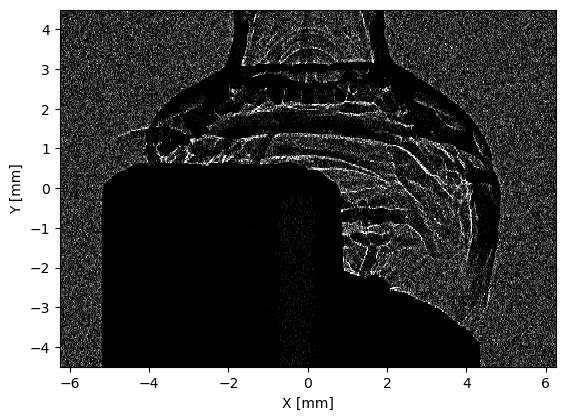

In [17]:
rf_100 = np.load(f"{ray_trace_dir_100}/ray_output.npy")
sh_100 = rtm.LIONZ_approx(r0 = rf_100, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad) # must center grid
sh_100.solve(d1=d1,d2=d2)

sh_100.histogram(bin_scale = 5)
fig, axs = plt.subplots()
cm='gray'

vmin=np.percentile(sh_100.H, 5)
vmax=np.percentile(sh_100.H, 90) #default is 90

clim=(0,vmax*3) # trial and error
sh_100.plot(axs, cmap=cm, clim=clim)

plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
# plt.savefig(f'{output_dir}/{Lens_Rad}mm.png', bbox_inches='tight')
# plt.close()

(-6.25, 6.25)

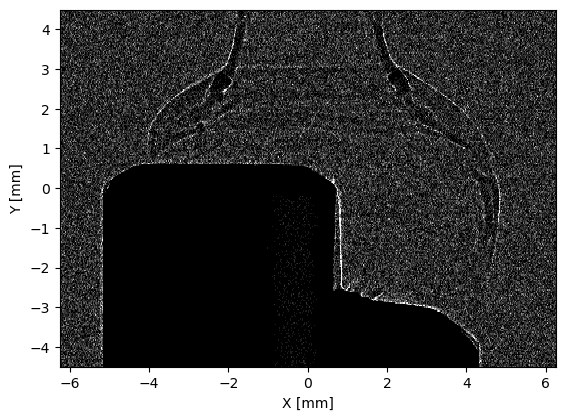

In [16]:
rf_010 = np.load(f"{ray_trace_dir_010}/ray_output.npy")
sh_010 = rtm.LIONZ_approx(r0 = rf_010, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad) # must center grid
sh_010.solve(d1=d1,d2=d2)

sh_010.histogram(bin_scale = 5)
fig, axs = plt.subplots()
cm='gray'

vmin=np.percentile(sh_010.H, 5)
vmax=np.percentile(sh_010.H, 90) #default is 90

clim=(0,vmax*3) # trial and error
sh_010.plot(axs, cmap=cm, clim=clim)

plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
# plt.savefig(f'{output_dir}/{Lens_Rad}mm.png', bbox_inches='tight')
# plt.close()

Text(0.5, 1.0, '3D Shield with Lens Radius = 20 mm')

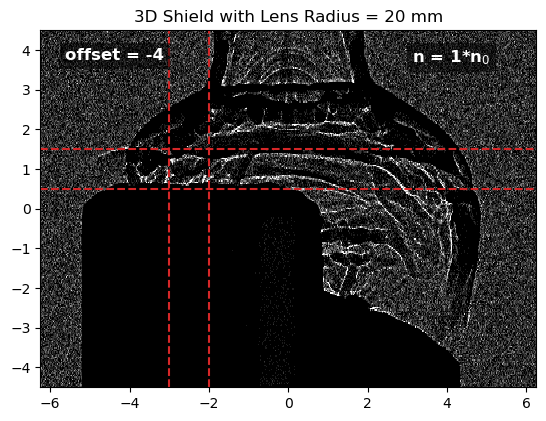

In [29]:
#track rays 
tracker_100 = rtm.Tracked_Shadowgraphy(r0 = rf_100, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad)
tracker_100.solve(d1, d2)
tracker_100.histogram(bin_scale = 5)

#define range 
x_upper = -2
x_lower = -3
y_upper = 1.5
y_lower= 0.5

fig, axs = plt.subplots()
tracker_100.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

scale = 1
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.title(f'3D Shield with Lens Radius = {Lens_Rad} mm')

# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi.jpg', bbox_inches='tight')

Text(0.5, 1.0, 'Ray ROI (Lens Radius = 20 mm)')

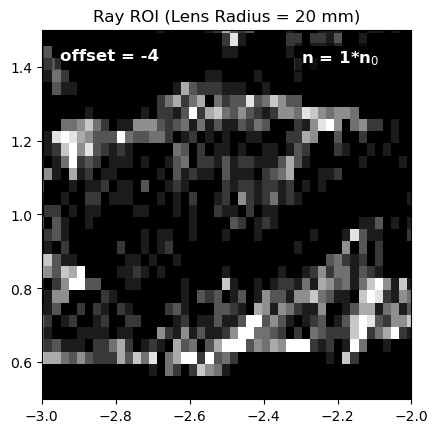

In [30]:
fig, axs = plt.subplots()
tracker_100.plot(axs, cmap=cm, clim=clim)
plt.ylim(y_lower, y_upper)
plt.xlim(x_lower, x_upper)

axs.text(0.7, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.title(f'Ray ROI (Lens Radius = {Lens_Rad} mm)')
# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi_zoom.jpg', bbox_inches='tight')

Text(0.5, 1.0, '3D Shield with Lens Radius = 20 mm')

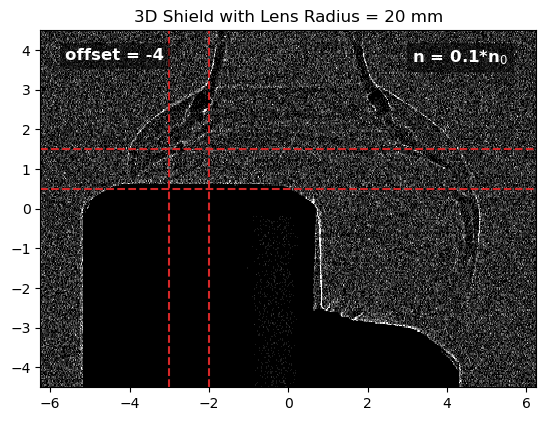

In [31]:
#track rays 
tracker_010 = rtm.Tracked_Shadowgraphy(r0 = rf_010, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad)
tracker_010.solve(d1, d2)
tracker_010.histogram(bin_scale = 5)

fig, axs = plt.subplots()
tracker_010.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

scale = 0.1
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.title(f'3D Shield with Lens Radius = {Lens_Rad} mm')

# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi.jpg', bbox_inches='tight')

Text(0.5, 1.0, 'Ray ROI (Lens Radius = 20 mm)')

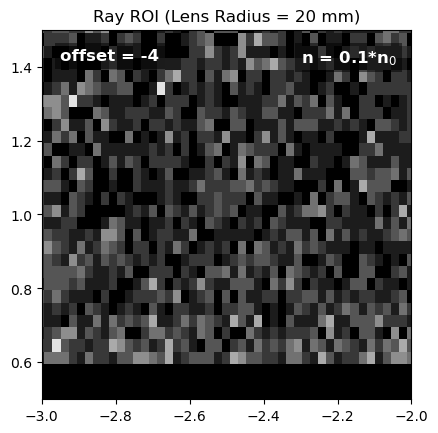

In [32]:
fig, axs = plt.subplots()
tracker_010.plot(axs, cmap=cm, clim=clim)
plt.ylim(y_lower, y_upper)
plt.xlim(x_lower, x_upper)

axs.text(0.7, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.title(f'Ray ROI (Lens Radius = {Lens_Rad} mm)')
# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi_zoom.jpg', bbox_inches='tight')

In [33]:
# find rays in region of interest from higher density
tagged_indices = []
for j in range(len(tracker_100.rf[0, :])):
    if ((tracker_100.rf[0, j] > x_lower) & (tracker_100.rf[0, j] < x_upper) & (tracker_100.rf[2, j] < y_upper) & (tracker_100.rf[2, j] > y_lower)):
        tagged_indices.append(j)

print('number of tagged rays:', len(tagged_indices))

number of tagged rays: 1850


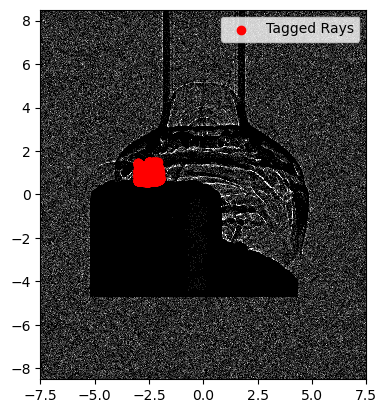

In [34]:
# validate that chosen rays are within the RoI
tracker_100.histogram(bin_scale=5)

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker_100.H, 5)
vmax=np.percentile(tracker_100.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker_100.plot(axs, cmap=cm, clim=clim)

tracker_100.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker_100.rf[0, tagged_indices]
final_y = tracker_100.rf[2, tagged_indices]

ax.scatter(final_x, final_y, color='red', label='Tagged Rays')
ax.legend()
# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged.jpg', bbox_inches='tight')

(0.0, 2.0)

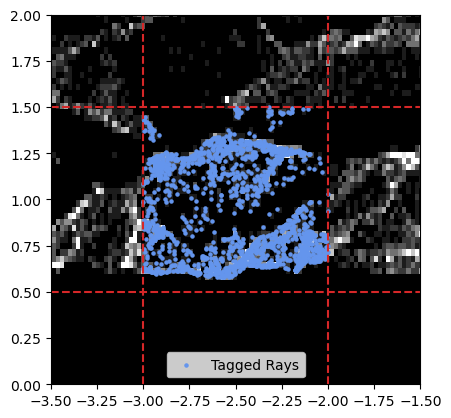

In [46]:
# zoom in on ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker_100.H, 5)
vmax=np.percentile(tracker_100.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker_100.plot(axs, cmap=cm, clim=clim)

tracker_100.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker_100.rf[0, tagged_indices]
final_y = tracker_100.rf[2, tagged_indices]

ax.scatter(final_x, final_y, color='cornflowerblue', label='Tagged Rays', s = 5)
plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

ax.legend()
plt.xlim(x_lower - 0.5, x_upper + 0.5)
plt.ylim(y_lower - 0.5, y_upper + 0.5)
# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged_zoom.jpg', bbox_inches='tight')

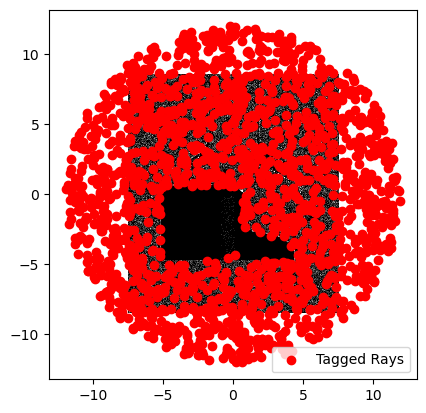

In [50]:
# plot rays that were in original ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker_010.H, 5)
vmax=np.percentile(tracker_010.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker_010.plot(axs, cmap=cm, clim=clim)

tracker_010.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker_010.rf[0, tagged_indices]
final_y = tracker_010.rf[2, tagged_indices]

#check that no rays are out of the domain
# for i in range(len(final_x)):
#     if((final_x[i] > 7.5) or (final_x[i] < -7.5) or (final_y[i] > 8) or (final_y[i] < -8)):
        # print('Ray', i, 'out of domain')

ax.scatter(final_x, final_y, color='red', label='Tagged Rays')
ax.legend()
# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged.jpg', bbox_inches='tight')

In [18]:
#check if there are any rays that are NaN (cut off by optics)
cut_rays_off0 = tracker_off0.get_cut_rays()

overlap = 0
for i in range(len(tagged_indices)):
    if tagged_indices[i] in cut_rays_off0:
        overlap += 1
print('Number of rays that were cut off when offset = 0 but not when offset = -4 in ROI:', overlap)

76057 rays filtered out (NaNs)
Number of rays that were cut off when offset = 0 but not when offset = -4 in ROI: 0
